# MLP 3-4-1 — Analisis Koefisien Korelasi R (Pearson)

Notebook ini melanjutkan `training_mlp_3input_closedloop.ipynb` dengan fokus pada **koefisien korelasi Pearson (R)** antara prediksi dan target, dihitung per-epoch pada train, validation, dan test.

---
## Perbedaan R dan R²

| Simbol | Nama | Rumus | Arti | Rentang |
|--------|------|-------|------|---------|
| **R** | Koefisien korelasi Pearson | $R = \frac{\text{cov}(y, \hat{y})}{\sigma_y \cdot \sigma_{\hat{y}}}$ | Seberapa kuat hubungan LINEAR antara prediksi dan target | −1 s.d. +1 |
| **R²** | Koefisien determinasi | $R^2 = 1 - \frac{\sum(y-\hat{y})^2}{\sum(y-\bar{y})^2}$ | Proporsi variasi target yang dijelaskan model | −∞ s.d. 1 |

**Kesimpulan:** $R \neq \sqrt{R^2}$ pada regresi non-linear. $R$ mengukur korelasi linear prediksi vs target, sedangkan $R^2$ mengukur kecocokan model secara keseluruhan. Dalam jurnal neural network, $R$ sering dipakai karena lebih mudah diinterpretasi sebagai "kekuatan hubungan linear" antara output model dan nilai sebenarnya.

---
**Arsitektur:** MLP 3-4-1
- Input (3): `[error, d_error, duty_percent]`
- Hidden: **1 hidden layer** berisi **4 neuron** (tanh)
- Output (1): `ΔDuty` (linear)
- Total parameter: 21

In [11]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
np.set_printoptions(suppress=True)

In [12]:
DATA_DIR = r'E:\\SEMESTER 8\\TA\\BUKU TA_YOEL\\DATA TRAINING 14 JUNI'
INCLUDE_F1 = True
HIDDEN = (4,)          # 1 hidden layer, 4 neuron
RANDOM_STATE = 42
TEST_SIZE = 0.20
VAL_FRACTION = 0.125
DUTY_MIN = 70.0
DUTY_MAX = 95.0
FEATURES = ['error', 'd_error', 'duty_percent']
TARGET = 'delta_duty'

## 1. Load & Gabung Data + Feature Engineering

Sama persis dengan notebook asli. Hanya pakai baris keputusan (`is_decision==1`), lalu buat fitur error, d_error, delta_duty per `global_episode`.

In [13]:
KEY = ['pressure_bar', 'duty_percent', 'setpoint_bar', 'episode_id', 'is_decision']
files = sorted(glob.glob(os.path.join(DATA_DIR, '*.csv')))
print(f'Ditemukan {len(files)} file CSV')

parts, gid = [], 0
for f in files:
    d = pd.read_csv(f)
    for c in KEY:
        d[c] = pd.to_numeric(d[c], errors='coerce')
    d = d.dropna(subset=KEY)
    for ep in sorted(d['episode_id'].unique()):
        gid += 1
        sub = d[d['episode_id'] == ep].copy()
        sub['global_episode'] = gid
        parts.append(sub)

df = pd.concat(parts, ignore_index=True)
print(f'Total episode global: {gid} | total baris: {len(df)}')

# ambil hanya titik keputusan
dec = df[df['is_decision'] == 1].copy().reset_index(drop=True)
dec['error']      = dec['setpoint_bar'] - dec['pressure_bar']
dec['d_error']    = dec.groupby('global_episode')['error'].diff().fillna(0.0)
dec['delta_duty'] = dec.groupby('global_episode')['duty_percent'].diff().shift(-1)

data = dec.dropna(subset=['delta_duty']).reset_index(drop=True)
if not INCLUDE_F1:
    data = data[np.isclose(data['setpoint_bar'], 0.30)].reset_index(drop=True)

print(f'Baris keputusan : {len(dec)}')
print(f'Baris siap latih: {len(data)}  (INCLUDE_F1={INCLUDE_F1})')

Ditemukan 12 file CSV
Total episode global: 16 | total baris: 4035
Baris keputusan : 469
Baris siap latih: 453  (INCLUDE_F1=True)


In [14]:
# distribusi target
print('=== Distribusi target ΔDuty ===')
print('  naik (>0) :', int((data[TARGET] > 0).sum()))
print('  turun (<0):', int((data[TARGET] < 0).sum()))
print('  tahan (=0):', int((data[TARGET] == 0).sum()))
print('  nilai unik:', sorted(data[TARGET].unique().tolist()))

=== Distribusi target ΔDuty ===
  naik (>0) : 161
  turun (<0): 91
  tahan (=0): 201
  nilai unik: [-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0]


## 2. Split Data Train / Validation / Test (70:10:20)

In [15]:
X = data[FEATURES].to_numpy(np.float32)
y = data[TARGET].to_numpy(np.float32)

idx = np.arange(len(data))
trainval_idx, test_idx = train_test_split(idx, test_size=TEST_SIZE,
    random_state=RANDOM_STATE, shuffle=True)
train_idx, val_idx = train_test_split(trainval_idx, test_size=VAL_FRACTION,
    random_state=RANDOM_STATE, shuffle=True)

X_train, X_val, X_test = X[train_idx], X[val_idx], X[test_idx]
y_train, y_val, y_test = y[train_idx], y[val_idx], y[test_idx]
print(f'Train {len(train_idx)} | Val {len(val_idx)} | Test {len(test_idx)}')

Train 316 | Val 46 | Test 91


## 3. Training dengan Tracking R (Koefisien Korelasi) per-Epoch

Kita latih MLP dengan `adam` + `partial_fit` agar bisa mencatat **R train**, **R validation**, dan **R test** setiap epoch. Ini menghasilkan kurva pembelajaran yang biasa ditampilkan di jurnal neural network.

Formula R (Pearson):

$$R = \frac{\sum(y_i - \bar{y})(\hat{y}_i - \bar{\hat{y}})}{\sqrt{\sum(y_i - \bar{y})^2} \cdot \sqrt{\sum(\hat{y}_i - \bar{\hat{y}})^2}}$$

- **R = +1** → prediksi dan target berkorelasi positif sempurna
- **R = 0** → tidak ada korelasi linear
- **R = −1** → prediksi dan target berkorelasi negatif sempurna

In [16]:
# scaling
scaler = StandardScaler().fit(X_train)
Xtr_s, Xva_s, Xte_s = scaler.transform(X_train), scaler.transform(X_val), scaler.transform(X_test)

# MLP dengan warm_start agar bisa partial_fit
mlp = MLPRegressor(
    hidden_layer_sizes=HIDDEN,
    activation='tanh',
    solver='adam',
    alpha=1e-3,
    learning_rate_init=0.02,
    max_iter=1,
    warm_start=True,
    random_state=RANDOM_STATE,
    batch_size=min(32, len(Xtr_s)),
    tol=1e-9,
    n_iter_no_change=10**9,
)

# tracking arrays
R_train_hist, R_val_hist, R_test_hist = [], [], []
MSE_train_hist, MSE_val_hist, MSE_test_hist = [], [], []
best_R_val, best_epoch_R, patience, bad = -np.inf, 0, 250, 0
best_MSE_val, best_epoch_MSE = np.inf, 0

for ep in range(1, 3001):
    mlp.partial_fit(Xtr_s, y_train)

    # prediksi
    pred_tr = mlp.predict(Xtr_s)
    pred_va = mlp.predict(Xva_s)
    pred_te = mlp.predict(Xte_s)

    # hitung R (koefisien korelasi Pearson)
    r_tr, _ = pearsonr(y_train, pred_tr)
    r_va, _ = pearsonr(y_val, pred_va)
    r_te, _ = pearsonr(y_test, pred_te)
    R_train_hist.append(r_tr)
    R_val_hist.append(r_va)
    R_test_hist.append(r_te)

    # hitung MSE
    mse_tr = mean_squared_error(y_train, pred_tr)
    mse_va = mean_squared_error(y_val, pred_va)
    mse_te = mean_squared_error(y_test, pred_te)
    MSE_train_hist.append(mse_tr)
    MSE_val_hist.append(mse_va)
    MSE_test_hist.append(mse_te)

    # catat R_val terbaik
    if r_va > best_R_val:
        best_R_val = r_va
        best_epoch_R = ep
        bad = 0
    else:
        bad += 1
        if bad >= patience:
            if ep > 500:
                break

    # catat MSE_val terbaik
    if mse_va < best_MSE_val - 1e-7:
        best_MSE_val = mse_va
        best_epoch_MSE = ep

print(f'Stop di epoch {len(R_train_hist)}')
print(f'Best Validation R  = {best_R_val:.6f} @ epoch {best_epoch_R}')
print(f'Best Validation MSE = {best_MSE_val:.6f} @ epoch {best_epoch_MSE}')

Stop di epoch 515
Best Validation R  = 0.969092 @ epoch 265
Best Validation MSE = 0.154250 @ epoch 259


## 4. Performa Final: R, R², dan Persamaan Garis Fit

Hitung metrik pada data test (yang **tidak pernah** dilihat model), plus persamaan garis regresi linear `Output ≈ a·Target + b` untuk ketiga subset (gaya jurnal).

In [17]:
# prediksi final pada train, val, test
pred_tr_final = mlp.predict(Xtr_s)
pred_va_final = mlp.predict(Xva_s)
pred_te_final = mlp.predict(Xte_s)

# R Pearson final
r_tr_final, _ = pearsonr(y_train, pred_tr_final)
r_va_final, _ = pearsonr(y_val, pred_va_final)
r_te_final, p_val = pearsonr(y_test, pred_te_final)

# R², RMSE, MAE — test
r2_final = r2_score(y_test, pred_te_final)
rmse_final = np.sqrt(mean_squared_error(y_test, pred_te_final))
mae_final = mean_absolute_error(y_test, pred_te_final)

# persamaan garis fit linear: Output ≈ a·Target + b
slope_tr, intercept_tr = np.polyfit(y_train, pred_tr_final, 1)
slope_va, intercept_va = np.polyfit(y_val, pred_va_final, 1)
slope_te, intercept_te = np.polyfit(y_test, pred_te_final, 1)

print('='*60)
print('HASIL AKHIR MLP 3-4-1')
print('='*60)
print(f'  R Train                    = {r_tr_final:.6f}')
print(f'  R Validation               = {r_va_final:.6f}')
print(f'  R Test                     = {r_te_final:.6f}')
print()
print(f'  R² Test                    = {r2_final:.6f}')
print(f'  RMSE Test                  = {rmse_final:.6f}')
print(f'  MAE Test                   = {mae_final:.6f}')
print(f'  p-value (signifikansi R)   = {p_val:.6e}')
print()
print(f'  Best epoch (R_val)         = {best_epoch_R}')
print(f'  Best epoch (MSE_val)       = {best_epoch_MSE}')
print()
print('Persamaan garis fit linear (Output ≈ a·Target + b):')
print(f'  Train      : Output ≈ {slope_tr:.4f}·Target + {intercept_tr:.4f}')
print(f'  Validation : Output ≈ {slope_va:.4f}·Target + {intercept_va:.4f}')
print(f'  Test       : Output ≈ {slope_te:.4f}·Target + {intercept_te:.4f}')

HASIL AKHIR MLP 3-4-1
  R Train                    = 0.962123
  R Validation               = 0.967353
  R Test                     = 0.947510

  R² Test                    = 0.893604
  RMSE Test                  = 0.518395
  MAE Test                   = 0.370389
  p-value (signifikansi R)   = 1.401298e-45

  Best epoch (R_val)         = 265
  Best epoch (MSE_val)       = 259

Persamaan garis fit linear (Output ≈ a·Target + b):
  Train      : Output ≈ 0.9271·Target + 0.0043
  Validation : Output ≈ 0.9916·Target + 0.0656
  Test       : Output ≈ 0.9527·Target + 0.0524


## 5. Gambar Utama: Scatter Output vs Target & Kurva MSE per-Epoch

**Baris atas (a):** 3 scatter plot — Training, Validation, Test — masing-masing menampilkan titik data (hitam), garis fit linear (berwarna), dan garis ideal Y=T (putus-putus).

**Baris bawah (b):** Kurva Mean Squared Error (MSE) per-epoch untuk Train, Validation, dan Test. Titik best validation performance ditandai dengan lingkaran hijau dan garis vertikal.

Cara membaca:
- **R** di pojok kiri atas tiap scatter: koefisien korelasi Pearson (semakin mendekati 1 semakin baik).
- **Fit line** (garis tegas berwarna): semakin dekat ke garis Y=T (putus-putus), semakin akurat model.
- **MSE validation** (oranye, baris bawah): mencapai minimum di epoch tertentu lalu datar → model sudah konvergen.
- **Gap MSE train vs test**: jika gap besar → overfitting; jika kecil → generalisasi baik.

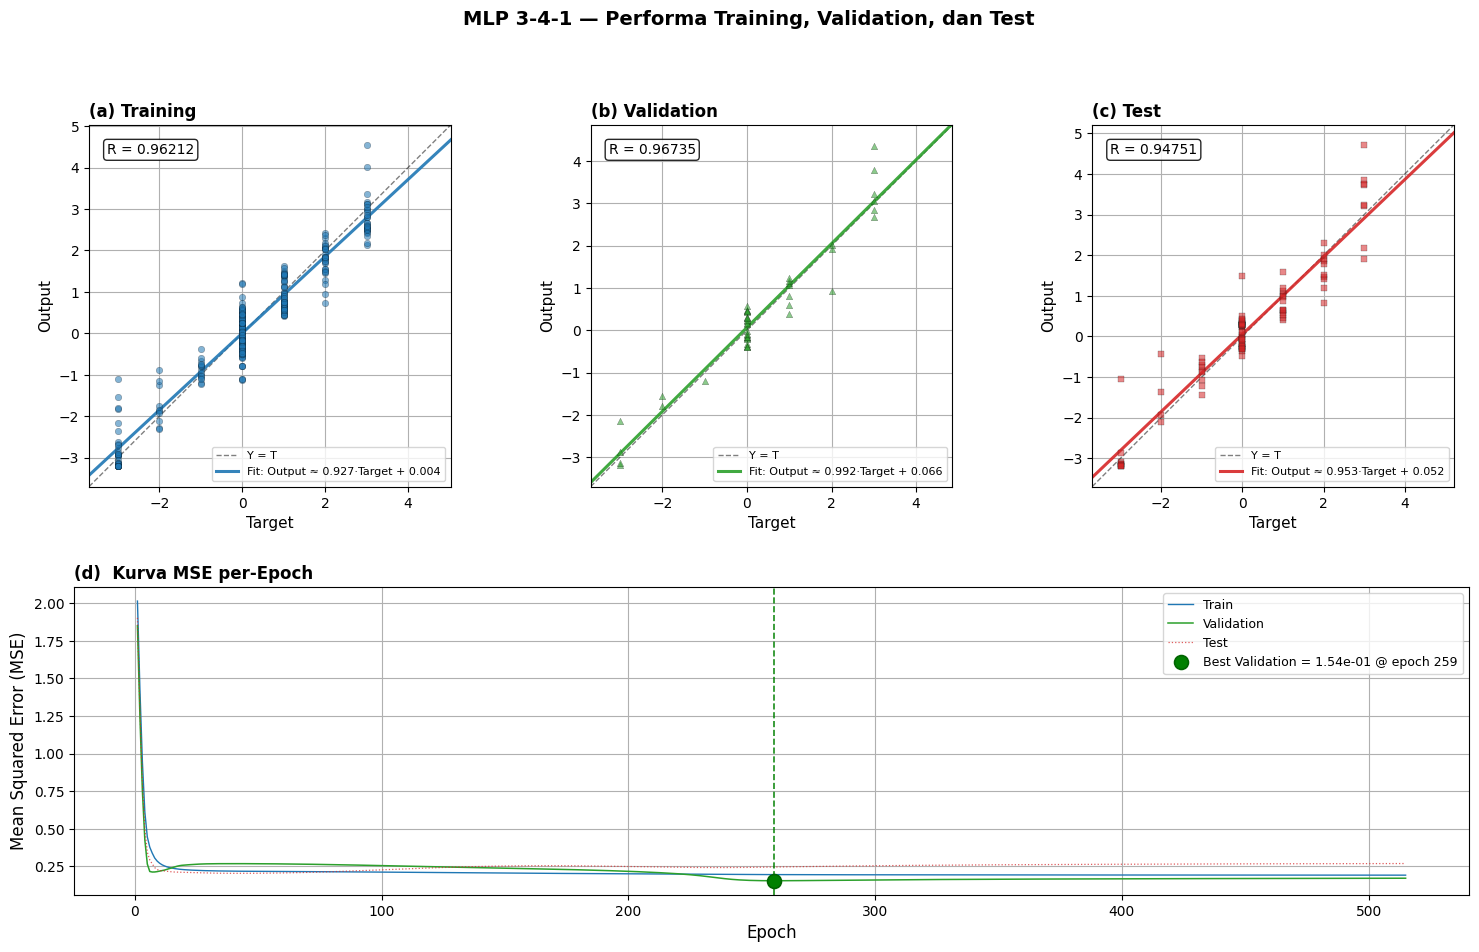

In [18]:
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(18, 10))
gs = GridSpec(2, 3, figure=fig, height_ratios=[1.0, 0.85], hspace=0.30, wspace=0.28)

epochs = np.arange(1, len(R_train_hist) + 1)

# ===== (a) Row 1: Scatter Output vs Target =====
for idx, (yt, yp, slope, intercept, r_val, color, title, mark) in enumerate([
    (y_train, pred_tr_final, slope_tr, intercept_tr, r_tr_final, '#1f77b4', 'Training', 'o'),
    (y_val,   pred_va_final, slope_va, intercept_va, r_va_final, '#2ca02c', 'Validation', '^'),
    (y_test,  pred_te_final, slope_te, intercept_te, r_te_final, '#d62728', 'Test', 's'),
]):
    ax = fig.add_subplot(gs[0, idx])
    ax.scatter(yt, yp, alpha=0.55, s=22, edgecolors='black', linewidth=0.25,
               color=color, marker=mark, zorder=3)

    # garis ideal Y=T
    lo, hi = min(yt.min(), yp.min()) - 0.5, max(yt.max(), yp.max()) + 0.5
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1.0, alpha=0.5, label='Y = T')

    # garis fit
    x_fit = np.linspace(lo, hi, 100)
    y_fit = slope * x_fit + intercept
    ax.plot(x_fit, y_fit, color=color, linewidth=2.2, alpha=0.9,
            label=f'Fit: Output ≈ {slope:.3f}·Target + {intercept:.3f}')

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel('Target', fontsize=11)
    ax.set_ylabel('Output', fontsize=11)
    ax.set_title(f'({chr(97+idx)}) {title}', fontsize=12, fontweight='bold', loc='left')
    ax.text(0.05, 0.95, f'R = {r_val:.5f}', transform=ax.transAxes,
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.85))
    ax.legend(fontsize=8, loc='lower right')
    ax.set_aspect('equal')

# ===== (b) Row 2: Kurva MSE =====
ax_mse = fig.add_subplot(gs[1, :])
ax_mse.plot(epochs, MSE_train_hist, color='#1f77b4', linewidth=1.0, label='Train')
ax_mse.plot(epochs, MSE_val_hist,   color='#2ca02c', linewidth=1.1, label='Validation')
ax_mse.plot(epochs, MSE_test_hist,  color='#d62728', linewidth=0.9,
            linestyle=':', alpha=0.75, label='Test')
ax_mse.axvline(best_epoch_MSE, color='green', linestyle='--', linewidth=1.2, alpha=0.9)
ax_mse.plot(best_epoch_MSE, best_MSE_val, 'o', color='green', markersize=10,
            markeredgecolor='darkgreen', markeredgewidth=1.2,
            label=f'Best Validation = {best_MSE_val:.2e} @ epoch {best_epoch_MSE}')
ax_mse.set_xlabel('Epoch', fontsize=12)
ax_mse.set_ylabel('Mean Squared Error (MSE)', fontsize=12)
ax_mse.set_title('(d)  Kurva MSE per-Epoch', fontsize=12, fontweight='bold', loc='left')
ax_mse.legend(fontsize=9, loc='upper right')

plt.suptitle('MLP 3-4-1 — Performa Training, Validation, dan Test',
             fontsize=14, fontweight='bold', y=0.995)
plt.show()

## 6. Deret Target vs Prediksi pada Data Test

Pelengkap: membandingkan ΔDuty target vs prediksi titik-per-titik di data test (urutan asli).

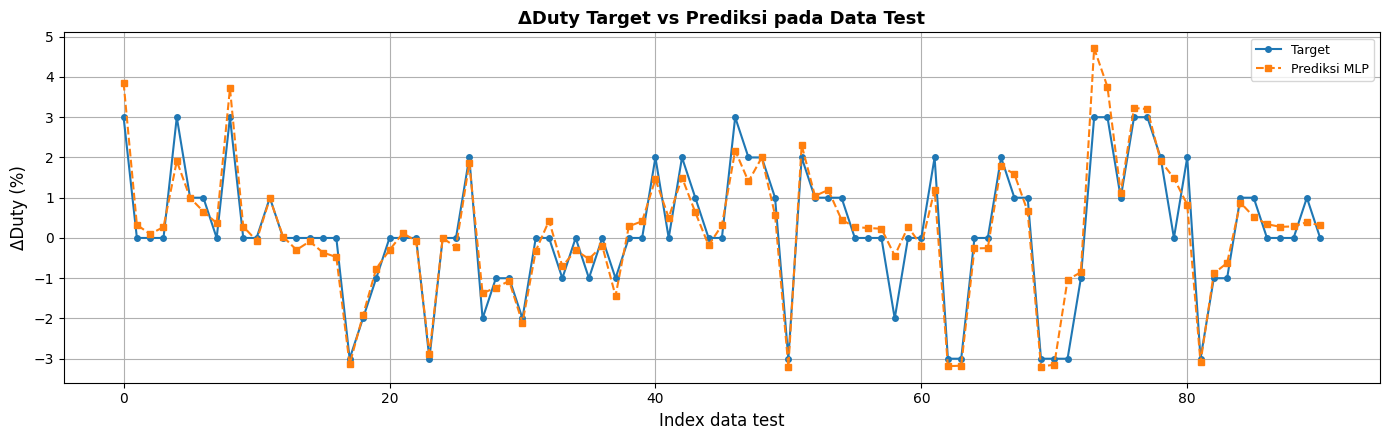

In [19]:
fig, ax = plt.subplots(figsize=(14, 4.5))
order = np.argsort(test_idx)
ax.plot(y_test[order], 'o-', ms=4, label='Target', color='#1f77b4')
ax.plot(pred_te_final[order], 's--', ms=4, label='Prediksi MLP', color='#ff7f0e')
ax.set_xlabel('Index data test', fontsize=12)
ax.set_ylabel('ΔDuty (%)', fontsize=12)
ax.set_title('ΔDuty Target vs Prediksi pada Data Test', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 7. Ringkasan Akhir

Pada epoch terbaik (berdasarkan R validation):

In [20]:
r_tr_best = R_train_hist[best_epoch_R - 1]
r_va_best = R_val_hist[best_epoch_R - 1]
r_te_best = R_test_hist[best_epoch_R - 1]

print('=' * 55)
print('  RINGKASAN PERFORMA (pada epoch terbaik) ')
print('=' * 55)
print(f'  Epoch terbaik (R_val max)    : {best_epoch_R}')
print(f'  R Train     @ epoch {best_epoch_R}      : {r_tr_best:.6f}')
print(f'  R Validation @ epoch {best_epoch_R}      : {r_va_best:.6f}')
print(f'  R Test      @ epoch {best_epoch_R}      : {r_te_best:.6f}')
print()
print(f'  R² Test final                : {r2_final:.6f}')
print(f'  RMSE Test final               : {rmse_final:.6f}')
print(f'  MAE Test final                : {mae_final:.6f}')
print()
print('  Catatan: R ≠ √(R²). R adalah korelasi Pearson,')
print('  sedangkan R² adalah koefisien determinasi.')
print('  Lihat penjelasan di sel paling atas notebook ini.')

  RINGKASAN PERFORMA (pada epoch terbaik) 
  Epoch terbaik (R_val max)    : 265
  R Train     @ epoch 265      : 0.961437
  R Validation @ epoch 265      : 0.969092
  R Test      @ epoch 265      : 0.950699

  R² Test final                : 0.893604
  RMSE Test final               : 0.518395
  MAE Test final                : 0.370389

  Catatan: R ≠ √(R²). R adalah korelasi Pearson,
  sedangkan R² adalah koefisien determinasi.
  Lihat penjelasan di sel paling atas notebook ini.
